# Part 4: ADALINE (Widrow & Hoff, 1960)

## Implementation of gradient descent-based learning

ADALINE (Adaptive Linear Neuron) was developed by Bernard Widrow and Tedd Hoff in 1960. It is an improvement over the Perceptron model. The key difference is the learning rule. While the Perceptron uses the class labels to learn the model weights, ADALINE uses the continuous predicted value from the net input to learn the weights. This allows for a more powerful learning rule based on minimizing a cost function, typically the Mean Squared Error (MSE).

The learning rule for ADALINE is based on gradient descent, where the weights are updated in the direction that minimizes the cost function. The weight update is performed using the following rule:
$w_j := w_j + \Delta w_j$, where $\Delta w_j = \eta \sum_{i} (y^{(i)} - \phi(z^{(i)})) x_j^{(i)}$

Here:
- $\eta$ is the learning rate.
- $y^{(i)}$ is the true class label of the i-th training sample.
- $\phi(z^{(i)})$ is the continuous value of the activation function (the net input).
- $x_j^{(i)}$ is the j-th feature of the i-th training sample.

Let's implement the ADALINE classifier.

In [2]:
import numpy as np

class AdalineGD(object):
    """ADALINE (Adaptive Linear Neuron) classifier.

    Parameters
    ------------
    eta : float
        Learning rate (between 0.0 and 1.0)
    n_iter : int
        Passes over the training dataset.
    random_state : int
        Random number generator seed for random weight
        initialization.

    Attributes
    -----------
    w_ : 1d-array
        Weights after fitting.
    cost_ : list
        Sum-of-squares cost function value in each epoch.

    """
    def __init__(self, eta=0.01, n_iter=50, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.random_state = random_state

    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_samples, n_features]
            Training vectors, where n_samples is the number of samples and
            n_features is the number of features.
        y : array-like, shape = [n_samples]
            Target values.

        Returns
        -------
        self : object

        """
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_iter):
            net_input = self.net_input(X)
            output = self.activation(net_input)
            errors = (y - output)
            self.w_[1:] += self.eta * X.T.dot(errors)
            self.w_[0] += self.eta * errors.sum()
            cost = (errors**2).sum() / 2.0
            self.cost_.append(cost)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, X):
        """Compute linear activation"""
        return X

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.0, 1, -1)

## Mean Square Error (MSE) minimization

The cost function used by ADALINE to learn the weights is the Mean Squared Error (MSE). It is defined as:
$J(w) = \frac{1}{2} \sum_{i} (y^{(i)} - \phi(z^{(i)}))^2$

By minimizing this cost function, the model learns the optimal weights for making predictions. We can visualize the learning process by plotting the cost at each epoch. A decreasing cost indicates that the model is learning.

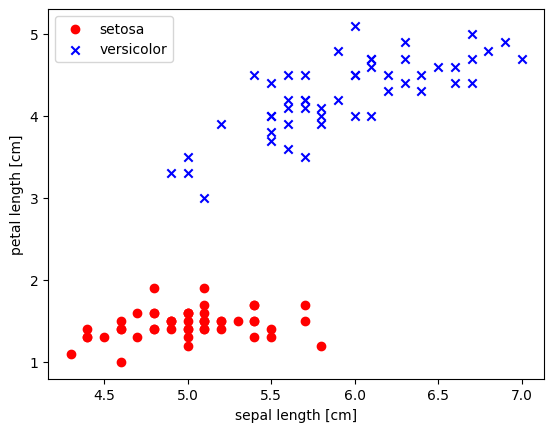

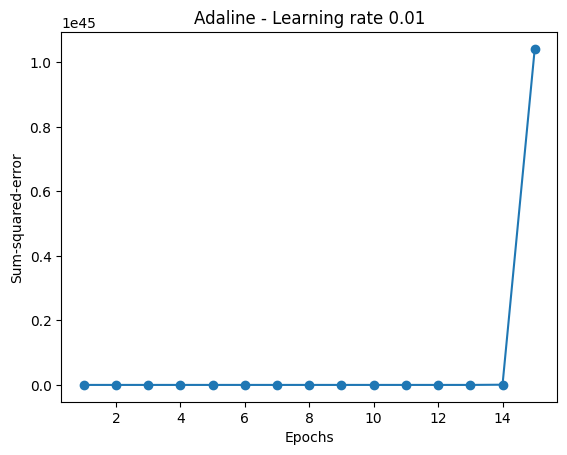

C:\Users\chiheb\AppData\Local\Temp\ipykernel_2612\1270705976.py:52: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


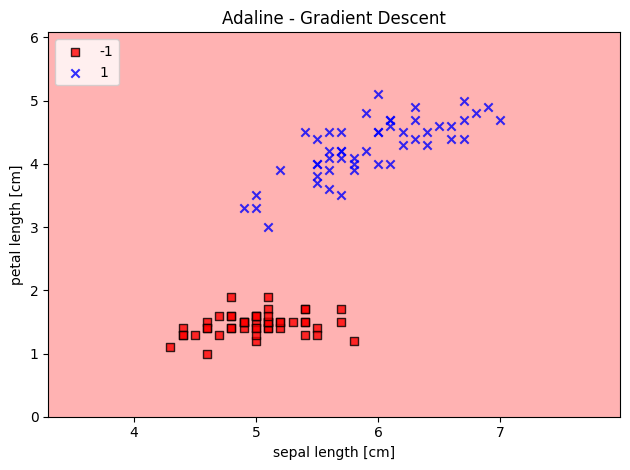

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Load the Iris dataset
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data', header=None)

# Extract sepal length and petal length
X = df.iloc[0:100, [0, 2]].values

# Extract class labels
y = df.iloc[0:100, 4].values
y = np.where(y == 'Iris-setosa', -1, 1)

# Plot the data
plt.scatter(X[:50, 0], X[:50, 1], color='red', marker='o', label='setosa')
plt.scatter(X[50:100, 0], X[50:100, 1], color='blue', marker='x', label='versicolor')
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')
plt.show()

# Train Adaline and plot the cost
ada = AdalineGD(n_iter=15, eta=0.01)
ada.fit(X, y)

plt.plot(range(1, len(ada.cost_) + 1), ada.cost_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Sum-squared-error')
plt.title('Adaline - Learning rate 0.01')
plt.show()

def plot_decision_regions(X, y, classifier, resolution=0.02):
    # setup marker generator and color map
    markers = ('s', 'x', 'o', '^', 'v')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class samples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')

plot_decision_regions(X, y, classifier=ada)
plt.title('Adaline - Gradient Descent')
plt.xlabel('sepal length [cm]')
plt.ylabel('petal length [cm]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Comparison with Perceptron on XOR problem

The XOR (exclusive OR) problem is a classic example of a non-linearly separable problem. This means that a linear classifier like the Perceptron or ADALINE cannot find a straight line to separate the classes.

Let's create the XOR dataset and attempt to train both a Perceptron and an ADALINE model on it. This will demonstrate the limitations of linear models.

Perceptron Accuracy on XOR: 0.5
ADALINE Accuracy on XOR: 0.5


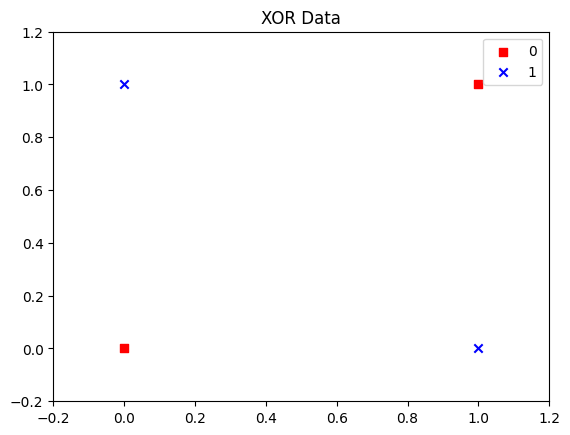

In [4]:
# XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# Perceptron
from sklearn.linear_model import Perceptron

perceptron = Perceptron(max_iter=1000, eta0=0.1, random_state=1)
perceptron.fit(X_xor, y_xor)
print('Perceptron Accuracy on XOR:', perceptron.score(X_xor, y_xor))

# Adaline
adaline_xor = AdalineGD(n_iter=100, eta=0.01)
adaline_xor.fit(X_xor, y_xor)
print('ADALINE Accuracy on XOR:', (adaline_xor.predict(X_xor) == y_xor).mean())

# Plot XOR data
plt.scatter(X_xor[y_xor == 0, 0], X_xor[y_xor == 0, 1], c='r', marker='s', label='0')
plt.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], c='b', marker='x', label='1')
plt.xlim([-0.2, 1.2])
plt.ylim([-0.2, 1.2])
plt.legend(loc='best')
plt.title('XOR Data')
plt.show()

## Effect of learning rate on convergence

The learning rate ($\eta$) is a crucial hyperparameter in gradient descent. It controls the size of the steps we take to minimize the cost function.
- A **small learning rate** can lead to slow convergence, requiring many epochs to reach the minimum.
- A **large learning rate** can cause the algorithm to overshoot the minimum, leading to divergence and a cost that increases over time.

Let's see how different learning rates affect the convergence of our ADALINE model.

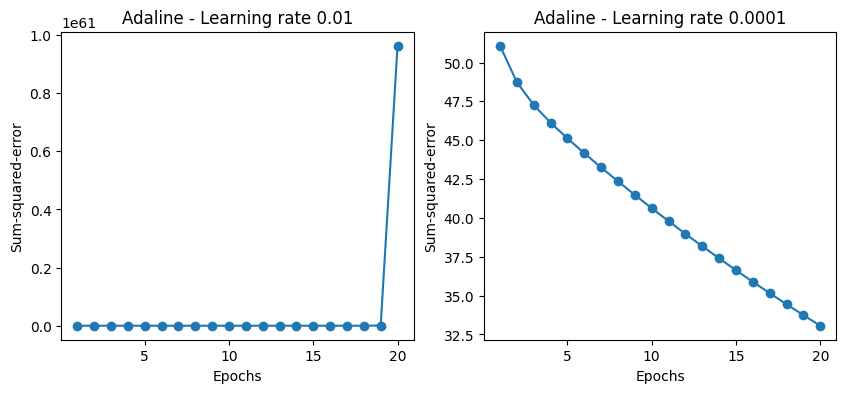

In [5]:
# Learning rates to try
etas = [0.01, 0.0001]
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

for i, eta in enumerate(etas):
    ada = AdalineGD(n_iter=20, eta=eta, random_state=1)
    ada.fit(X, y)
    ax[i].plot(range(1, len(ada.cost_) + 1), ada.cost_, marker='o')
    ax[i].set_xlabel('Epochs')
    ax[i].set_ylabel('Sum-squared-error')
    ax[i].set_title('Adaline - Learning rate {}'.format(eta))

plt.show()

## Importance of data standardization

Gradient descent can be sensitive to the scale of the features. If features have very different scales, the cost function surface can become elongated, making it harder for gradient descent to find the minimum.

**Standardization** is a common feature scaling technique that rescales features to have a mean of 0 and a standard deviation of 1. The formula for standardization is:
$x'_{j} = \frac{x_j - \mu_j}{\sigma_j}$

Let's apply standardization to our data and see how it affects the convergence of the ADALINE model.

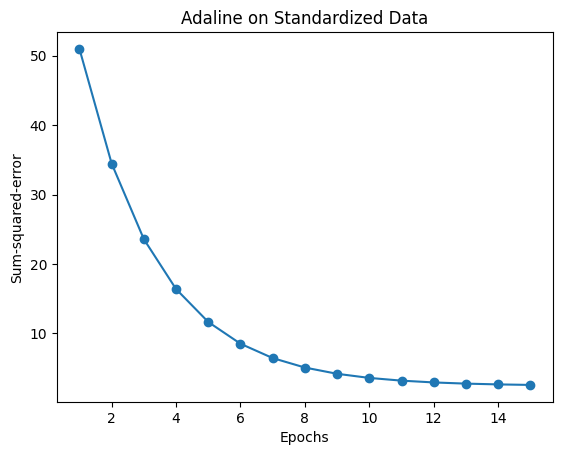

C:\Users\chiheb\AppData\Local\Temp\ipykernel_2612\1270705976.py:52: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


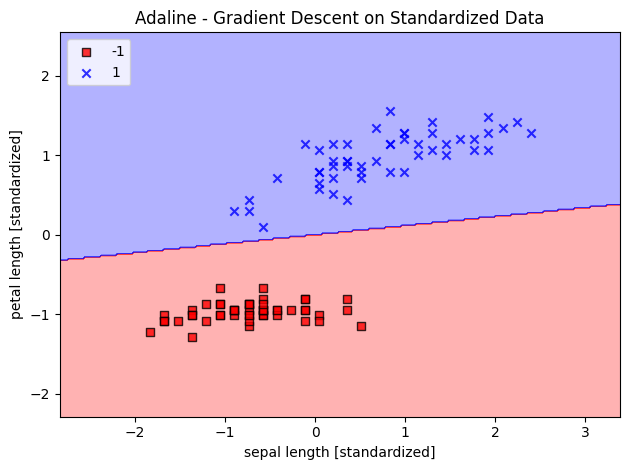

In [6]:
# Standardize the data
X_std = np.copy(X)
X_std[:, 0] = (X[:, 0] - X[:, 0].mean()) / X[:, 0].std()
X_std[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

# Train Adaline on standardized data
ada_std = AdalineGD(n_iter=15, eta=0.01)
ada_std.fit(X_std, y)

# Plot cost
plt.plot(range(1, len(ada_std.cost_) + 1), ada_std.cost_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Sum-squared-error')
plt.title('Adaline on Standardized Data')
plt.show()

# Plot decision boundary
plot_decision_regions(X_std, y, classifier=ada_std)
plt.title('Adaline - Gradient Descent on Standardized Data')
plt.xlabel('sepal length [standardized]')
plt.ylabel('petal length [standardized]')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

## Batch vs Stochastic vs Mini-batch Gradient Descent

There are three main variations of gradient descent, which differ in how much data is used to compute the gradient of the cost function at each step:

- **Batch Gradient Descent**: The entire training dataset is used to compute the gradient at each epoch. This is what we have implemented so far. It is computationally expensive but provides a stable convergence.
- **Stochastic Gradient Descent (SGD)**: The gradient is computed for each individual training sample. This is much faster but the cost function fluctuates more.
- **Mini-batch Gradient Descent**: This is a compromise between the two. The gradient is computed for a small batch of training samples. This is the most common approach in deep learning.

Let's implement Stochastic Gradient Descent and compare it to Batch Gradient Descent.

C:\Users\chiheb\AppData\Local\Temp\ipykernel_2612\1270705976.py:52: UserWarning: You passed a edgecolor/edgecolors ('black') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(x=X[y == cl, 0],


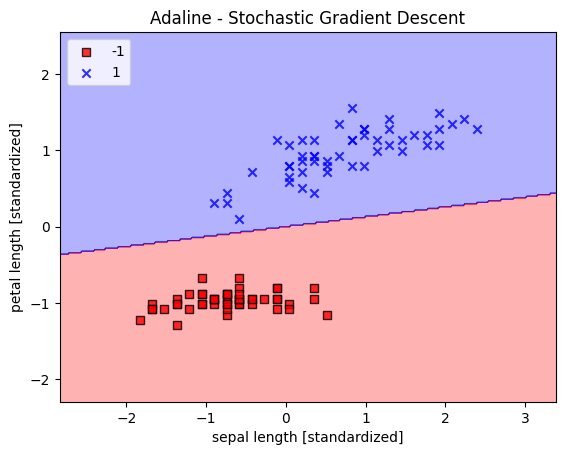

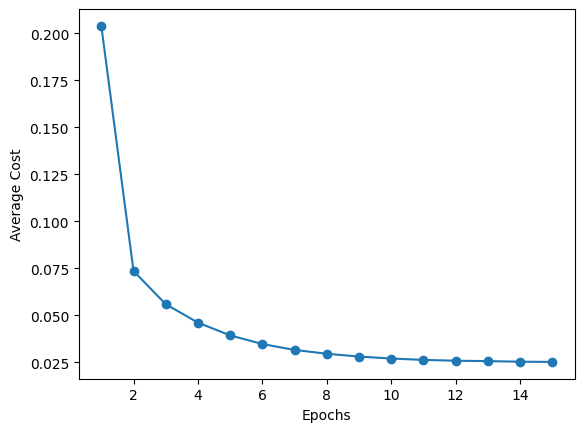

In [7]:
class AdalineSGD(object):
    """ADAptive LInear NEuron classifier with Stochastic Gradient Descent.

    Parameters
    ------------
    eta : float
        Learning rate (between 0.0 and 1.0)
    n_iter : int
        Passes over the training dataset.
    shuffle : bool (default: True)
        Shuffles training data every epoch if True to prevent cycles.
    random_state : int
        Random number generator seed for random weight
        initialization.


    Attributes
    -----------
    w_ : 1d-array
        Weights after fitting.
    cost_ : list
        Sum-of-squares cost function value averaged over all
        training samples in each epoch.

        
    """
    def __init__(self, eta=0.01, n_iter=10, shuffle=True, random_state=None):
        self.eta = eta
        self.n_iter = n_iter
        self.w_initialized = False
        self.shuffle = shuffle
        self.random_state = random_state
        
    def fit(self, X, y):
        """ Fit training data.

        Parameters
        ----------
        X : {array-like}, shape = [n_samples, n_features]
            Training vectors, where n_samples is the number of samples and
            n_features is the number of features.
        y : array-like, shape = [n_samples]
            Target values.

        Returns
        -------
        self : object

        """
        self._initialize_weights(X.shape[1])
        self.cost_ = []
        for i in range(self.n_iter):
            if self.shuffle:
                X, y = self._shuffle(X, y)
            cost = []
            for xi, target in zip(X, y):
                cost.append(self._update_weights(xi, target))
            avg_cost = sum(cost) / len(y)
            self.cost_.append(avg_cost)
        return self

    def partial_fit(self, X, y):
        """Fit training data without reinitializing the weights"""
        if not self.w_initialized:
            self._initialize_weights(X.shape[1])
        if y.ravel().shape[0] > 1:
            for xi, target in zip(X, y):
                self._update_weights(xi, target)
        else:
            self._update_weights(X, y)
        return self

    def _shuffle(self, X, y):
        """Shuffle training data"""
        r = self.rgen.permutation(len(y))
        return X[r], y[r]
    
    def _initialize_weights(self, m):
        """Initialize weights to small random numbers"""
        self.rgen = np.random.RandomState(self.random_state)
        self.w_ = self.rgen.normal(loc=0.0, scale=0.01, size=1 + m)
        self.w_initialized = True
        
    def _update_weights(self, xi, target):
        """Apply Adaline learning rule to update the weights"""
        output = self.activation(self.net_input(xi))
        error = (target - output)
        self.w_[1:] += self.eta * xi.dot(error)
        self.w_[0] += self.eta * error
        cost = 0.5 * error**2
        return cost
    
    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def activation(self, X):
        """Compute linear activation"""
        return X

    def predict(self, X):
        """Return class label after unit step"""
        return np.where(self.activation(self.net_input(X)) >= 0.0, 1, -1)

# Train Adaline with SGD
ada_sgd = AdalineSGD(n_iter=15, eta=0.01, random_state=1)
ada_sgd.fit(X_std, y)

# Plot decision boundary
plot_decision_regions(X_std, y, classifier=ada_sgd)
plt.title('Adaline - Stochastic Gradient Descent')
plt.xlabel('sepal length [standardized]')
plt.ylabel('petal length [standardized]')
plt.legend(loc='upper left')
plt.show()

# Plot cost
plt.plot(range(1, len(ada_sgd.cost_) + 1), ada_sgd.cost_, marker='o')
plt.xlabel('Epochs')
plt.ylabel('Average Cost')
plt.show()

## Adaptation for regression tasks

ADALINE can be easily adapted for regression tasks by removing the final activation function (the quantizer). In this case, the output of the model is the raw net input, $\phi(z) = z$. The model then directly predicts a continuous value instead of a class label.

The rest of the algorithm, including the cost function and weight update rule, remains the same.

## Application on Iris dataset

Let's apply our ADALINE classifier to the full Iris dataset. We will train it to classify all three species: Setosa, Versicolor, and Virginica. Since ADALINE is a binary classifier, we will use the One-vs-Rest (OvR) strategy. This involves training one classifier per class, with the samples of that class as positive samples and all other samples as negatives.

In [8]:
from sklearn.datasets import load_iris

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# Standardize features
X_iris_std = np.copy(X_iris)
for i in range(X_iris.shape[1]):
    X_iris_std[:, i] = (X_iris[:, i] - X_iris[:, i].mean()) / X_iris[:, i].std()

# One-vs-Rest Adaline
classifiers = []
for i in range(len(np.unique(y_iris))):
    y_ovr = np.where(y_iris == i, 1, -1)
    ada = AdalineSGD(n_iter=20, eta=0.01, random_state=1)
    ada.fit(X_iris_std, y_ovr)
    classifiers.append(ada)

# Make predictions
def predict_ovr(X):
    predictions = np.array([clf.net_input(X) for clf in classifiers]).T
    return np.argmax(predictions, axis=1)

y_pred = predict_ovr(X_iris_std)
print('Accuracy on Iris dataset:', (y_pred == y_iris).mean())

Accuracy on Iris dataset: 0.8533333333333334


## Extensions with momentum and learning rate decay

We can further improve the gradient descent algorithm with a couple of extensions:

- **Momentum**: This technique helps to accelerate gradient descent in the relevant direction and dampen oscillations. It adds a fraction of the previous weight update to the current one.
- **Learning Rate Decay**: This involves gradually reducing the learning rate over time. This allows for larger steps at the beginning of training and smaller, more fine-tuned steps as the algorithm approaches the minimum.

These extensions can lead to faster convergence and a better final model.